# Bayesian Logistic Regression Models

## Overview: Create a few BLR models for each umpire with different feature subsets and compare the posterior predictives


---
## Project Workflow:
1. **Install and Import Necessary Libraries**
2. **Create Model Feature Sets**
3. **Create Models**
4. **Sample Posterior & Save Context**
5. **Compare Models**


# Step 1: Install and Import Necessary Libraries


In [7]:
import pymc as pm
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import os
import json

# Step 2: Create Model Feature Sets

In [8]:
# Define priors using a dictionary of {feature_name: prior_mean}
# Model 1: mixed features
mixed = {
    'balls': 0, 'strikes': 0, 'zone': 1, 'pfx_x': 1, 'pfx_z': 0,
    'plate_x': -1, 'plate_z': -1, 'pitch_location': -2,
    'vx0': 0, 'vy0': 0, 'vz0': 0,
    'sz_top': 1, 'sz_bot': 1,
    'pitch_type_CH': 1, 'pitch_type_CS': 0, 'pitch_type_CU': 1, 'pitch_type_EP': -1,
    'pitch_type_FA': 1, 'pitch_type_FC': -0.5, 'pitch_type_FF': 1, 'pitch_type_FO': -1,
    'pitch_type_FS': 1, 'pitch_type_KC': -1, 'pitch_type_KN': -1, 'pitch_type_SC': -1,
    'pitch_type_SI': -1, 'pitch_type_SL': -1, 'pitch_type_ST': 1, 'pitch_type_SV': -1,
    'stand_R': 0, 'p_throws_R': 0
}

# Model 2: pitch tyes
pitch_types = {
    'pitch_type_CH': 1,
    'pitch_type_CS': 0,
    'pitch_type_CU': 1,
    'pitch_type_EP': -1,
    'pitch_type_FA': 1,
    'pitch_type_FC': -0.5,
    'pitch_type_FF': 1,
    'pitch_type_FO': -1,
    'pitch_type_FS': 1,
    'pitch_type_KC': -1,
    'pitch_type_KN': -1,
    'pitch_type_SC': -1,
    'pitch_type_SI': -1,
    'pitch_type_SL': -1,
    'pitch_type_ST': 1,
    'pitch_type_SV': -1,
}

# Model 3: physical features
phys_feats = {
    'zone': 1,
    'pfx_x': 1,
    'pfx_z': 0,
    'plate_x': -1,
    'plate_z': -1,
    'pitch_location': -2,
    'vx0': 0,
    'vy0': 0,
    'vz0': 0,
}

#  Final model
refined = {
    'pfx_x': 1,
    'plate_x': -1,
    'plate_z': -1,
    'pitch_location': -2,
    'sz_top': 1,
    'sz_bot': 1,
    'pitch_type_CH': 1,
    'pitch_type_CS': 0,
    'pitch_type_CU': 1,
    'pitch_type_EP': -1,
    'pitch_type_FA': 1,
    'pitch_type_FC': -0.5,
    'pitch_type_FF': 1,
    'pitch_type_FO': -1,
    'pitch_type_FS': 1,
    'pitch_type_KC': -1,
    'pitch_type_KN': -1,
    'pitch_type_SC': -1,
    'pitch_type_SI': -1,
    'pitch_type_SL': -1,
    'pitch_type_ST': 1,
    'pitch_type_SV': -1
}

feature_sets = {
    "1_all_feats": mixed, #TODO: uncomment
    "2_pitch_types": pitch_types,
    "3_phys_feats": phys_feats,
    "4_refined": refined
}

umpire_files = ["Umpire_1_cleaned.csv", "Umpire_2_cleaned.csv", "Umpire_3_cleaned.csv"]

# to store results locally
models = {}
traces = {}
summaries_priors = {}
summaries_posterior = {}

# Step 3: Create Models

In [10]:
for model_name, priors in feature_sets.items():
    data = pd.read_csv(f"data/cleaned/{umpire_files[0]}") # TODO: add func for all files
    coords = {'n_obs': range(len(data))}

    with pm.Model(coords=coords) as model:
        print(f"... Starting loop for {model_name}")
        # Intercept
        intercept = pm.Normal('intercept', mu=0, sigma=2)

        # Create priors and store references
        betas = {}
        for name, mu in priors.items():
            betas[name] = pm.Normal(f'beta_{name}', mu=mu, sigma=2)

        # Compute logits using vectorized sum
        logits = intercept + sum(betas[name] * data[name] for name in priors)

        # Logistic transformation
        p = pm.Deterministic('p', pm.math.sigmoid(logits))

        # Bernoulli likelihood
        y = pm.Bernoulli('y', p=p, observed=data['error_in_decision'])

        # Prior predictive
        prior_pred = pm.sample_prior_predictive(samples=100) # TODO: switch back to 500 samples

        # see what kind of data the model believes is likely just from the priors.
        summary = az.summary(prior_pred, hdi_prob=0.95)
        beta_values = summary.loc[summary.index.str.startswith("beta_")]

        models[model_name] = model
        summaries_priors[model_name] = beta_values
        
        # Save prior definitions for later reference/rebuild
        with open(f"data/rebuild/{model_name}_priors.json", "w") as f:
            json.dump(priors, f)

... Starting loop for 1_all_feats


Sampling: [beta_balls, beta_p_throws_R, beta_pfx_x, beta_pfx_z, beta_pitch_location, beta_pitch_type_CH, beta_pitch_type_CS, beta_pitch_type_CU, beta_pitch_type_EP, beta_pitch_type_FA, beta_pitch_type_FC, beta_pitch_type_FF, beta_pitch_type_FO, beta_pitch_type_FS, beta_pitch_type_KC, beta_pitch_type_KN, beta_pitch_type_SC, beta_pitch_type_SI, beta_pitch_type_SL, beta_pitch_type_ST, beta_pitch_type_SV, beta_plate_x, beta_plate_z, beta_stand_R, beta_strikes, beta_sz_bot, beta_sz_top, beta_vx0, beta_vy0, beta_vz0, beta_zone, intercept, y]
arviz - WARNING - Shape validation failed: input_shape: (1, 100), minimum_shape: (chains=2, draws=4)
Sampling: [beta_pitch_type_CH, beta_pitch_type_CS, beta_pitch_type_CU, beta_pitch_type_EP, beta_pitch_type_FA, beta_pitch_type_FC, beta_pitch_type_FF, beta_pitch_type_FO, beta_pitch_type_FS, beta_pitch_type_KC, beta_pitch_type_KN, beta_pitch_type_SC, beta_pitch_type_SI, beta_pitch_type_SL, beta_pitch_type_ST, beta_pitch_type_SV, intercept, y]


... Starting loop for 2_pitch_types


arviz - WARNING - Shape validation failed: input_shape: (1, 100), minimum_shape: (chains=2, draws=4)
Sampling: [beta_pfx_x, beta_pfx_z, beta_pitch_location, beta_plate_x, beta_plate_z, beta_vx0, beta_vy0, beta_vz0, beta_zone, intercept, y]


... Starting loop for 3_phys_feats


arviz - WARNING - Shape validation failed: input_shape: (1, 100), minimum_shape: (chains=2, draws=4)
Sampling: [beta_pfx_x, beta_pitch_location, beta_pitch_type_CH, beta_pitch_type_CS, beta_pitch_type_CU, beta_pitch_type_EP, beta_pitch_type_FA, beta_pitch_type_FC, beta_pitch_type_FF, beta_pitch_type_FO, beta_pitch_type_FS, beta_pitch_type_KC, beta_pitch_type_KN, beta_pitch_type_SC, beta_pitch_type_SI, beta_pitch_type_SL, beta_pitch_type_ST, beta_pitch_type_SV, beta_plate_x, beta_plate_z, beta_sz_bot, beta_sz_top, intercept, y]


... Starting loop for 4_refined


arviz - WARNING - Shape validation failed: input_shape: (1, 100), minimum_shape: (chains=2, draws=4)


## Visualizations 
not needed for calculations below. Just a sanity check of spread of priors, data actually in data set.

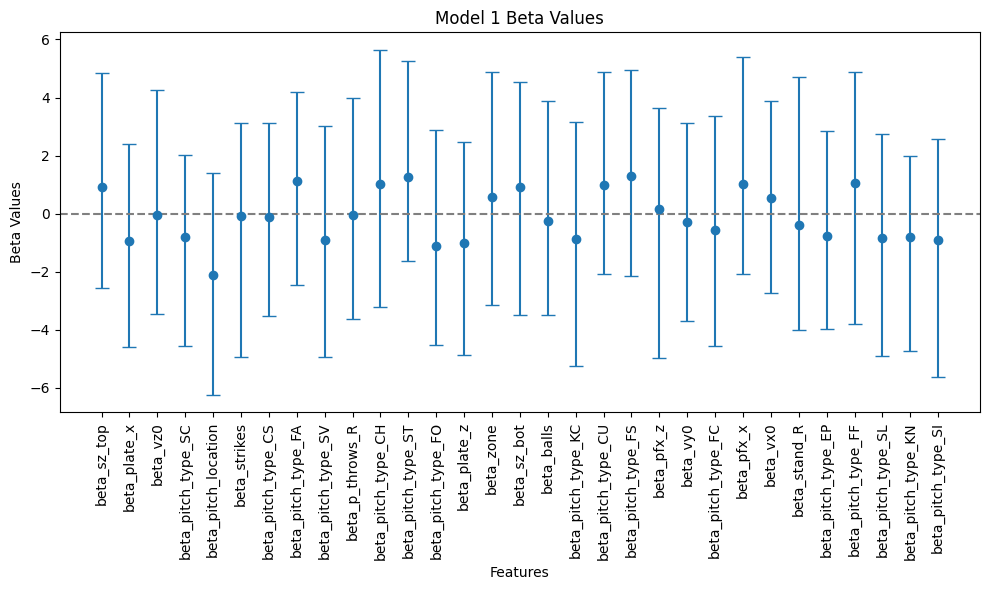

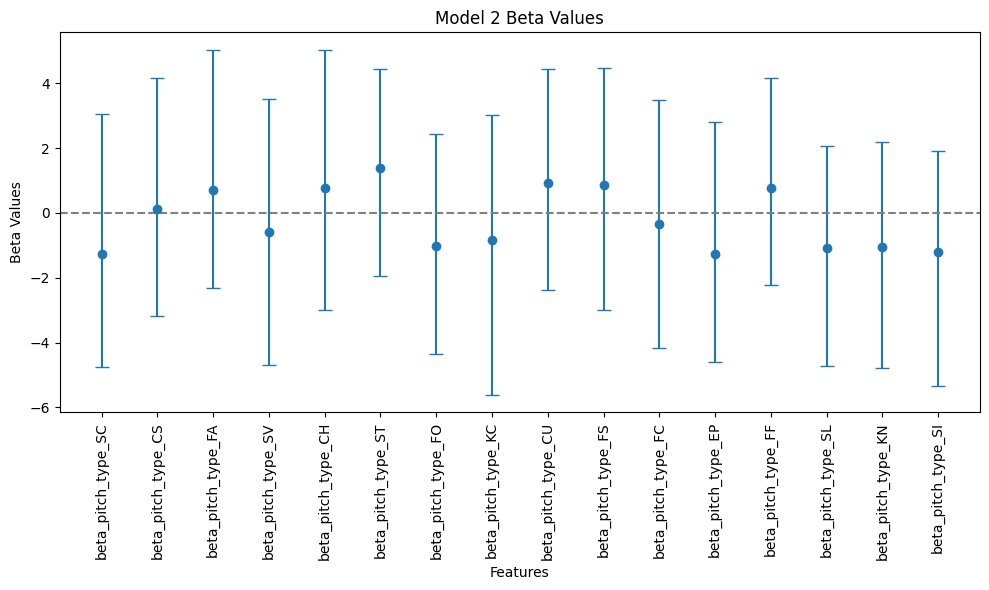

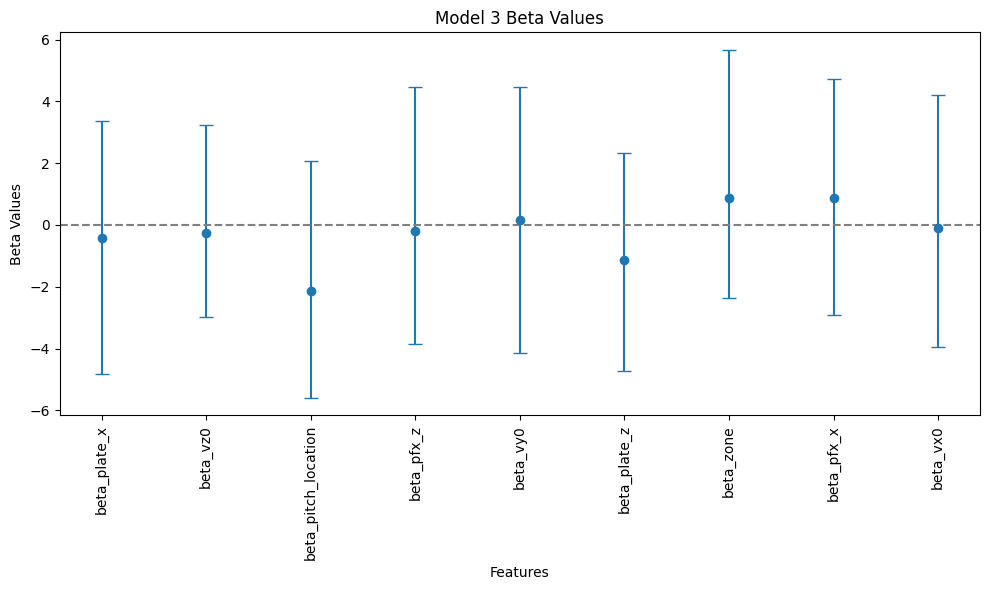

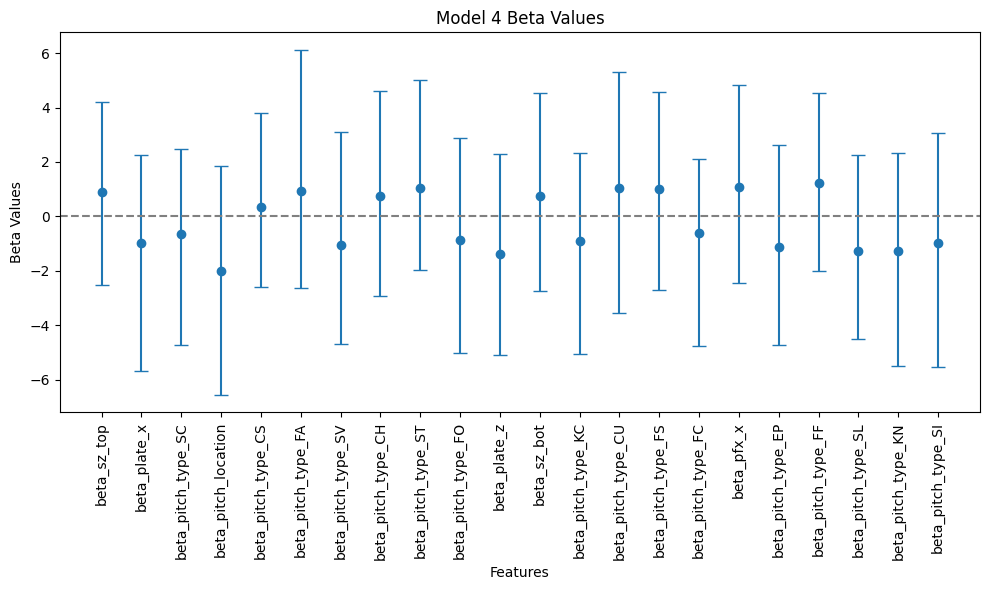

In [ ]:
log_path = f"data/rebuild/model_prior_summaries.txt"
open(log_path, "w").close() # Clear previous logs

with open(log_path, "a") as log_file:
  for index, (name, model) in enumerate(models.items()):
        print(f"\n\n\n---------- Printing {name} Summary ----------", file=log_file)
        print(summaries_priors[name], file=log_file)
    
        plt.figure(figsize=(10, 6))
        plt.errorbar(summaries_priors[name].index, summaries_priors[name]['mean'],
                    yerr=[summaries_priors[name]['mean'] - summaries_priors[name]['hdi_2.5%'], summaries_priors[name]['hdi_97.5%'] - summaries_priors[name]['mean']],
                    fmt='o', capsize=5)
        plt.axhline(0, color='gray', linestyle='--')
        plt.xlabel('Features')
        plt.ylabel('Beta Values')
        plt.title(f'Model {index + 1} Beta Values')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

# Step 4: Sample Posterior & Save Context

In [ ]:
def sample_posterior(model_name, model):
    with model:
        trace = pm.sample(1000, tune=1000, target_accept=0.95, cores=4, return_inferencedata=True, idata_kwargs={"log_likelihood": True})
        
        az.to_netcdf(trace, f"rdata/rebuild/{model_name}_traces.nc")

Run models individually bc they often crash. After trace is saved then we can do heavy computations on it.

In [ ]:
model_name = "1_all_feats"
if model_name in feature_sets and model_name in models:
    sample_posterior(model_name, models[model_name])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_balls, beta_strikes, beta_zone, beta_pfx_x, beta_pfx_z, beta_plate_x, beta_plate_z, beta_pitch_location, beta_vx0, beta_vy0, beta_vz0, beta_sz_top, beta_sz_bot, beta_pitch_type_CH, beta_pitch_type_CS, beta_pitch_type_CU, beta_pitch_type_EP, beta_pitch_type_FA, beta_pitch_type_FC, beta_pitch_type_FF, beta_pitch_type_FO, beta_pitch_type_FS, beta_pitch_type_KC, beta_pitch_type_KN, beta_pitch_type_SC, beta_pitch_type_SI, beta_pitch_type_SL, beta_pitch_type_ST, beta_pitch_type_SV, beta_stand_R, beta_p_throws_R]


Output()

ValueError: Not enough samples to build a trace.

In [ ]:
model_name = "2_pitch_types"
if model_name in feature_sets and model_name in models:
    sample_posterior(model_name, models[model_name])

In [ ]:
model_name = "3_phys_feats"
if model_name in feature_sets and model_name in models:
    sample_posterior(model_name, models[model_name])

In [ ]:
model_name = "4_refined"
if model_name in feature_sets and model_name in models:
    sample_posterior(model_name, models[model_name])

If context gets disrupted, add the traces back to local context! Run steps 1,2 again.

In [ ]:
for model_name in feature_sets:
    # rebuild models
    with open(f"data/results/{model_name}_priors.json") as f:
        priors = json.load(f)
        model = build_model("3_phys_feats", priors)

    # rebuild traces
    trace_path = os.path.join("data/rebuild", f"{model_name}_traces.nc")
    
    if os.path.exists(trace_path):
        traces[model_name] = az.from_netcdf(trace_path)
        print(f"✅ Loaded trace for: {model_name}")
    else:
        print(f"❌ Trace file not found: {trace_path}")

In [ ]:
# Compare models
if len(traces) > 1:
    model_compare = az.compare(traces, ic="loo")
    display(model_compare)

In [ ]:
def posterior_calcs(trace, model_name, model):
    summary = az.summary(trace, hdi_prob=0.95)
    summaries_posterior[model_name] = summary

    # Posterior predictive
    ppc = pm.sample_posterior_predictive(trace, model=model)
    trace.extend(ppc)
    
    # Plt posterior
    az.plot_ppc(trace)
    plt.title(f"Posterior Predictive Check: {model_name}")
    plt.show()
    
    # plt forest of betas
    az.plot_forest(trace, var_names=[f"beta_{k}" for k in priors.keys()], combined=True)
    plt.title(f"Posterior Forest Plot: {model_name}")
    plt.show()

    # for debugging
        # print(summary.sort_values("mean", ascending=False))